In [10]:
# ─── Imports ──────────────────────────────────────────────────────────────────
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings("ignore")

from tqdm import tqdm
import pandas as pd
tqdm.pandas()

from datetime import datetime
from langdetect import detect, DetectorFactory

# Para que la detección de idioma sea reproducible
DetectorFactory.seed = 42

RANDOM_SEED = 42

# COFIGURACIÓN GENERAL
ROOT_PATH = r'C:\Users\Aaron\Documents\arxiv_cs_dataset_exploration'

now = datetime.now() # Obtener la fecha y hora actual
date_time = now.strftime("%d_%m_%Y_%H_%M_%S")
 
# --- Rutas de entrada ---
DATA_PATH_TOP_10     = ROOT_PATH + r'\dataset\arxiv_cs_top10_augmented.parquet'
DATA_PATH_ARTICULOS_UAM     = ROOT_PATH + r'\dataset\Articulos.csv'
# --- Rutas de salida ---
DATA_PATH_TOP_10_LIMPIO_BAELINE = ROOT_PATH + r'\dataset\arxiv_cs_top10_limpieza_baseline_augmented_' + date_time +'.parquet'
DIR_MODELS = ROOT_PATH + r'\models'
DIR_RESULTADOS = ROOT_PATH + r'\resultados'

#os.makedirs(DIR_MODELS, exist_ok = True)
#os.makedirs(DIR_RESULTADOS, exist_ok = True)


# now = datetime.now() # Obtener la fecha y hora actual
# date_time = now.strftime("%d_%m_%Y_%H_%M_%S")

# OUTPUT_DIR        = r'C:\Users\AaronMCC\Documents\Rest-Mex2025\resultados\res_' + date_time

# os.mkdir(OUTPUT_DIR)

# BEST_MODEL_PATH   = r'C:\Users\AaronMCC\Documents\Rest-Mex2025\models\best_model_' + date_time + '.pt'
# CSV_HISTORY       = OUTPUT_DIR + r'\training_history_' + date_time + '.csv'
# CSV_OPTUNA        = OUTPUT_DIR + r'\optuna_results_' + date_time + '.csv'
# PLOT_CURVES       = OUTPUT_DIR + r'\curvas_entrenamiento_' + date_time + '.png'
# PLOT_CONFUSION    = OUTPUT_DIR + r'\confusion_matrix_' + date_time + '.png'





In [11]:
# Carga del Dataset
df_top10 = pd.read_parquet(DATA_PATH_TOP_10)
print("Dataset cargado: OK!")

Dataset cargado: OK!


In [13]:
print(df_top10.columns)

Index(['title', 'abstract', 'cs_primary', 'texto_limpio', 'aug_method', 'id'], dtype='object')


In [14]:
df_top10

,title,abstract,cs_primary,texto_limpio,aug_method,id
0,Dynamic Guidance Adversarial Distillation with...,In the realm of Adversarial Distillation (AD...,cs.CV,in the realm of adversarial distillation ad st...,original,None
1,Visual Anchors Are Strong Information Aggregat...,In the realm of Multimodal Large Language Mo...,cs.CV,in the realm of multimodal large language mode...,original,None
2,Multisensor Data Fusion for Reliable Obstacle ...,"In this work, we propose a new approach that...",cs.RO,in this work we propose a new approach that co...,original,None
3,Root-to-Leaf Scheduling in Write-Optimized Trees,Write-optimized dictionaries are a class of ...,cs.DS,writeoptimized dictionaries are a class of cac...,original,None
4,From Claims to Evidence: A Unified Framework a...,While numerous architectures for medical ima...,cs.AI,while numerous architectures for medical image...,original,None
...,...,...,...,...,...,...
713058,The SEED Internet Emulator and Its Application...,"In cybersecurity courses, it is quite challe...",cs.CR,in cybersecurity courses it is quite challengi...,original,None
713059,Visual and Textual Prior Guided Mask Assemble ...,Few-shot segmentation (FSS) aims to segment ...,cs.CV,fewshot segmentation fss aims to segment the n...,original,None
713060,Autoregressive Text Generation Beyond Feedback...,"Autoregressive state transitions, where pred...",cs.LG,autoregressive state transitions where predict...,original,None
713061,,,cs.NA,The discovery of fast numerical solutions led ...,back_translation,aug_bt_cs.NA_000424


## Preprocesamiento de texto
Limpiar los abstracts antes de vectorizar:

- [x] Convertir a minúsculas.
- [x] Eliminar caracteres especiales, números sueltos y puntuación.
- [x] Eliminar stopwords en inglés.
- [x] Aplicar lematización 



In [11]:
# Carga del Dataset
df_top10 = pd.read_parquet(DATA_PATH_TOP_10)
print("Dataset cargado: OK!")


def limpieza_baseline(text):
    if not isinstance(text, str) or len(text) < 5:
        return ""
    text = text.lower()
    # URLs y correos
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S*@\S*\s?', '', text)
    # Eliminación de fórmulas matemáticas en LaTeX
    text = re.sub(r'\$.*?\$', '', text)
    # Eliminación de comandos y macros de LaTeX
    text = re.sub(r'\\[a-zA-Z]+\{.*?\}', '', text)
    # Solo letras y espacios
    text = re.sub(r'[^a-z\s]', '', text)
    # Normalización de espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Iniciando limpieza... Puede demorar unos minutos")

# Aplicar limpieza sobre el abstract
df_top10['texto_limpio'] = df_top10['abstract'].progress_apply(limpieza_baseline)

# Conservar solo columnas relevantes
df_top10 = df_top10[['title', 'abstract', 'cs_primary', 'texto_limpio']]

# Guardar el DF
df_top10.to_parquet(DATA_PATH_TOP_10_LIMPIO_BAELINE)
print("Limpieza completada y guardada: OK!")

Dataset cargado: OK!
Iniciando limpieza... Puede demorar unos minutos


100%|████████████████████████████████████████████████████████████████████████| 642077/642077 [02:13<00:00, 4796.63it/s]


Limpieza completada y guardada: OK!


In [12]:
df_top10

,title,abstract,cs_primary,texto_limpio
1,A limit relation for entropy and channel capac...,"In a quantum mechanical model, Diosi, Feldma...",cs.IT,in a quantum mechanical model diosi feldmann a...
4,On-line Viterbi Algorithm and Its Relationship...,"In this paper, we introduce the on-line Vite...",cs.DS,in this paper we introduce the online viterbi ...
6,Sparsely-spread CDMA - a statistical mechanics...,"Sparse Code Division Multiple Access (CDMA),...",cs.IT,sparse code division multiple access cdma a va...
9,Capacity of a Multiple-Antenna Fading Channel ...,Given a multiple-input multiple-output (MIMO...,cs.IT,given a multipleinput multipleoutput mimo chan...
12,On Punctured Pragmatic Space-Time Codes in Blo...,This paper considers the use of punctured co...,cs.IT,this paper considers the use of punctured conv...
...,...,...,...,...
892968,A Quick Glance at Quantum Cryptography,The recent application of the principles of ...,cs.CR,the recent application of the principles of qu...
892978,A simple proof of the unconditional security o...,Quantum key distribution is the most well-kn...,cs.CR,quantum key distribution is the most wellknown...
892984,Secure Classical Bit Commitment using Fixed Ca...,If mutually mistrustful parties A and B cont...,cs.CR,if mutually mistrustful parties a and b contro...
892989,Unconditionally Secure Commitment of a Certifi...,In a secure bit commitment protocol involvin...,cs.CR,in a secure bit commitment protocol involving ...


## Entranamiento

In [15]:
# Carga del corpus limpio 
df = pd.read_parquet(DATA_PATH_TOP_10)
print(f"Registros cargados : {len(df):,}")
print(f"Clases disponibles : {df['cs_primary'].nunique()}")
print(df['cs_primary'].value_counts())

Registros cargados : 713,063
Clases disponibles : 10
cs_primary
cs.LG    163511
cs.CV    158664
cs.CL     80661
cs.IT     48902
cs.AI     48726
cs.RO     46445
cs.CR     45571
cs.SY     41511
cs.NA     40034
cs.DS     39038
Name: count, dtype: int64


In [16]:
# División train / validation 
X = df['texto_limpio'].fillna("")
y = df['cs_primary']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"Train : {len(X_train):,} documentos")
print(f"Val   : {len(X_val):,} documentos")

Train : 570,450 documentos
Val   : 142,613 documentos


In [17]:
# Pesos de clase calculados sobre el conjunto de entrenamiento
clases      = y_train.unique()
K           = len(clases)
N_total     = len(y_train)
conteos     = y_train.value_counts()

pesos = {clase: N_total / (K * conteos[clase]) for clase in clases}

print("Pesos de clase:")
for clase, peso in sorted(pesos.items(), key=lambda x: x[1], reverse=True):
    print(f"  {clase:10s}  n={conteos[clase]:>7,}  peso={peso:.4f}")

Pesos de clase:
  cs.DS       n= 31,230  peso=1.8266
  cs.NA       n= 32,027  peso=1.7812
  cs.SY       n= 33,209  peso=1.7178
  cs.CR       n= 36,457  peso=1.5647
  cs.RO       n= 37,156  peso=1.5353
  cs.AI       n= 38,981  peso=1.4634
  cs.IT       n= 39,121  peso=1.4582
  cs.CL       n= 64,529  peso=0.8840
  cs.CV       n=126,931  peso=0.4494
  cs.LG       n=130,809  peso=0.4361


In [18]:
# Vectorización TF-IDF 
vectorizer = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),       # unigramas + bigramas
    sublinear_tf=True,        # escala logarítmica en frecuencias
    min_df=2,                 # ignorar términos en menos de 2 docs
    stop_words='english'      # stopwords 
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)

print(f"Dimensión matriz TF-IDF train : {X_train_tfidf.shape}")
print(f"Dimensión matriz TF-IDF val   : {X_val_tfidf.shape}")

Dimensión matriz TF-IDF train : (570450, 50000)
Dimensión matriz TF-IDF val   : (142613, 50000)


In [19]:
# Entrenamiento Regresión Logística
model = LogisticRegression(
    class_weight=pesos,    # compensar desbalance
    max_iter=1000,
    C=1.0,
    solver='saga',         # eficiente para corpus grandes
    random_state=RANDOM_SEED,
    n_jobs=-1              # usar todos los núcleos disponibles
)

print("Entrenando modelo...")
model.fit(X_train_tfidf, y_train)
print("Entrenamiento completado.")

Entrenando modelo...
Entrenamiento completado.


In [20]:
# Evaluación interna sobre validación arXiv 
y_pred_val = model.predict(X_val_tfidf)

print("=" * 60)
print("EVALUACIÓN INTERNA — Validación arXiv (20%)")
print("=" * 60)
print(classification_report(y_val, y_pred_val, digits=4))

macro_f1_val = f1_score(y_val, y_pred_val, average='macro')
print(f"Macro F1 validación arXiv : {macro_f1_val:.4f}")

EVALUACIÓN INTERNA — Validación arXiv (20%)
              precision    recall  f1-score   support

       cs.AI     0.4898    0.5680    0.5260      9745
       cs.CL     0.8335    0.8769    0.8547     16132
       cs.CR     0.8215    0.8919    0.8553      9114
       cs.CV     0.9101    0.8703    0.8898     31733
       cs.DS     0.8416    0.9264    0.8820      7808
       cs.IT     0.8561    0.8917    0.8736      9781
       cs.LG     0.8396    0.7144    0.7720     32702
       cs.NA     0.8453    0.9194    0.8808      8007
       cs.RO     0.8297    0.8760    0.8522      9289
       cs.SY     0.7769    0.8402    0.8073      8302

    accuracy                         0.8219    142613
   macro avg     0.8044    0.8375    0.8194    142613
weighted avg     0.8268    0.8219    0.8224    142613

Macro F1 validación arXiv : 0.8194


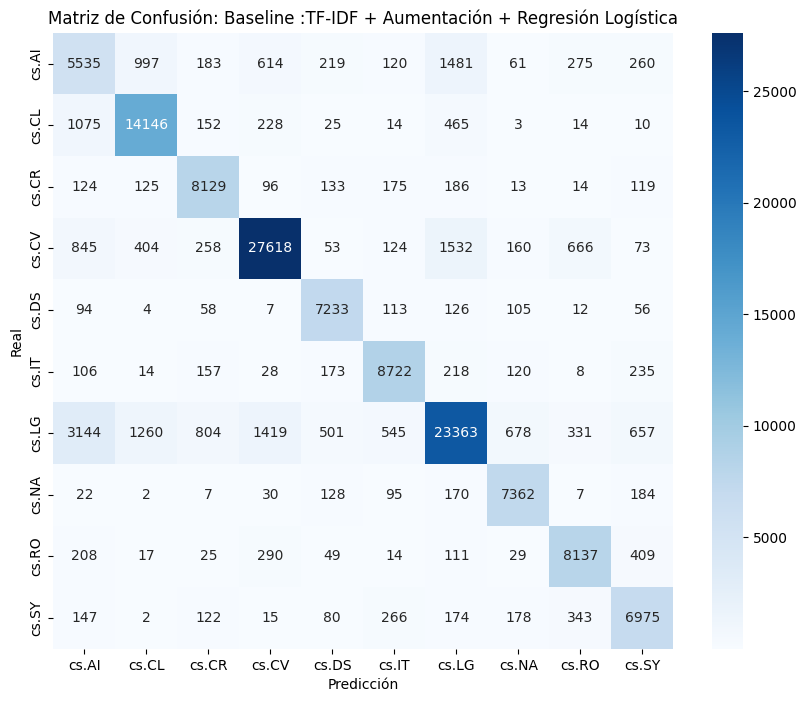

In [22]:
# Matriz de Confusión 
etiquetas = model.classes_

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, y_pred_val, labels = etiquetas), annot=True, fmt='d', cmap='Blues', xticklabels=etiquetas, yticklabels=etiquetas)
plt.title('Matriz de Confusión: Baseline :TF-IDF + Aumentación + Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [24]:
# Evaluación transferencia pura sobre UAM-A 


# Cargar el dataset UAM-A
df_uam = pd.read_csv(DATA_PATH_ARTICULOS_UAM)   


def limpieza_baseline(text):
    # Detección de Idioma (Filtro inicial)
    try:
        if detect(text) != 'en':
            return ""
    except:
        return ""
        
    if not isinstance(text, str) or len(text) < 5:
        return ""
    text = text.lower()
    # URLs y correos
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S*@\S*\s?', '', text)
    # Eliminación de fórmulas matemáticas en LaTeX
    text = re.sub(r'\$.*?\$', '', text)
    # Eliminación de comandos y macros de LaTeX
    text = re.sub(r'\\[a-zA-Z]+\{.*?\}', '', text)
    # Solo letras y espacios
    text = re.sub(r'[^a-z\s]', '', text)
    # Normalización de espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Aplicar la misma limpieza ligera usada en el corpus arXiv
df_uam['texto_limpio'] = df_uam['Resumen'].apply(limpieza_baseline)

# Eliminar las filas que quedaron vacías por el filtro de idioma
df_uam = df_uam[df_uam['texto_limpio'] != ""].reset_index(drop=True)

# Vectorizar con el TF-IDF 
X_uam_tfidf = vectorizer.transform(df_uam['texto_limpio'].fillna(""))

print(f"Documentos UAM-A vectorizados: {X_uam_tfidf.shape[0]:,}")

Documentos UAM-A vectorizados: 746


In [25]:
df_uam

,Resumen,texto_limpio
0,Self stabilization effects were experimentally...,self stabilization effects were experimentally...
1,The current work on stellarators being carried...,the current work on stellarators being carried...
2,We prove that a graph is 4-colorable if and on...,we prove that a graph is colorable if and only...
3,Trapped electron modes in stellarators can be ...,trapped electron modes in stellarators can be ...
4,This paper contains viewgraphs on the existenc...,this paper contains viewgraphs on the existenc...
...,...,...
741,Topic discovery is finding the main idea of la...,topic discovery is finding the main idea of la...
742,This study examines the release kinetics of hy...,this study examines the release kinetics of hy...
743,A layer of sheared poloidal velocity (or radia...,a layer of sheared poloidal velocity or radial...
744,The studies of MHD stability properties of ste...,the studies of mhd stability properties of ste...


In [26]:
# Predicciones sobre UAM-A
y_pred_uam = model.predict(X_uam_tfidf)

# Guardar predicciones en el DataFrame
df_uam['pred_baseline'] = y_pred_uam

print("Distribución de predicciones sobre UAM-A:")
print(pd.Series(y_pred_uam).value_counts().to_string())

Distribución de predicciones sobre UAM-A:
cs.AI    265
cs.NA    146
cs.SY    112
cs.CL     57
cs.DS     57
cs.CR     32
cs.CV     32
cs.LG     21
cs.IT     14
cs.RO     10


In [27]:
df_uam

,Resumen,texto_limpio,pred_baseline
0,Self stabilization effects were experimentally...,self stabilization effects were experimentally...,cs.SY
1,The current work on stellarators being carried...,the current work on stellarators being carried...,cs.RO
2,We prove that a graph is 4-colorable if and on...,we prove that a graph is colorable if and only...,cs.DS
3,Trapped electron modes in stellarators can be ...,trapped electron modes in stellarators can be ...,cs.LG
4,This paper contains viewgraphs on the existenc...,this paper contains viewgraphs on the existenc...,cs.SY
...,...,...,...
741,Topic discovery is finding the main idea of la...,topic discovery is finding the main idea of la...,cs.CL
742,This study examines the release kinetics of hy...,this study examines the release kinetics of hy...,cs.NA
743,A layer of sheared poloidal velocity (or radia...,a layer of sheared poloidal velocity or radial...,cs.NA
744,The studies of MHD stability properties of ste...,the studies of mhd stability properties of ste...,cs.NA


In [43]:
df_uam.to_csv(DIR_RESULTADOS + r'\predicciones_uam_baseline_con_aug_' + date_time +'.csv')
print(DIR_RESULTADOS + r'\predicciones_uam_baseline_con_aug_' + date_time +'.csv')

C:\Users\Aaron\Documents\arxiv_cs_dataset_exploration\resultados\predicciones_uam_baseline_con_aug_04_04_2026_17_10_54.csv


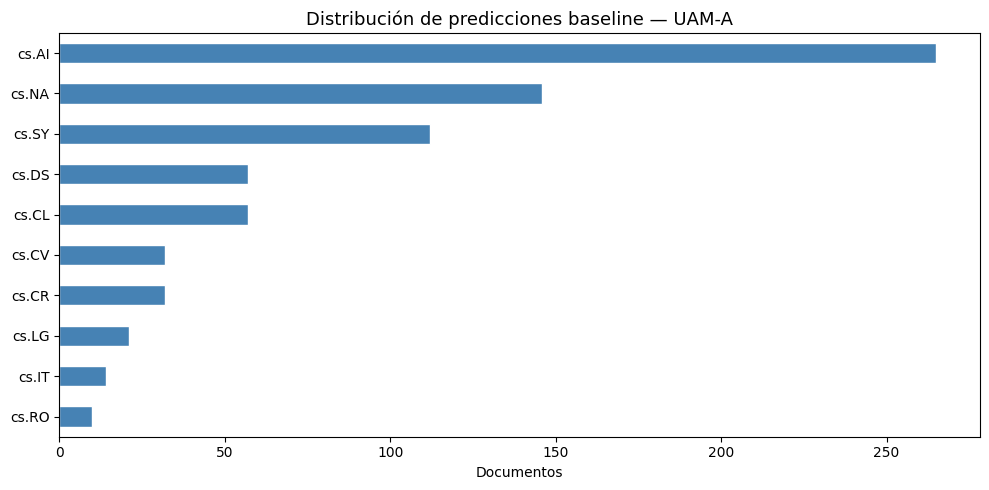

In [33]:
# Métricas UAM-A 

# y_true_uam = df_uam['etiqueta_manual']
# print("=" * 60)
# print("EVALUACIÓN TRANSFERENCIA PURA — UAM-A (733 docs)")
# print("=" * 60)
# print(classification_report(y_true_uam, y_pred_uam, digits=4))
# macro_f1_uam = f1_score(y_true_uam, y_pred_uam, average='macro')
# print(f"Macro F1 UAM-A : {macro_f1_uam:.4f}")

# Solo la distribución de predicciones
fig, ax = plt.subplots(figsize=(10, 5))
pd.Series(y_pred_uam).value_counts().sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Distribución de predicciones baseline — UAM-A", fontsize=13)
ax.set_xlabel("Documentos")
plt.tight_layout()
plt.savefig(DIR_RESULTADOS + "pred_baseline_uam_aumentcion_' + date_time +'.png", dpi=150)
plt.show()

In [31]:
# ─── Guardar modelo y vectorizador para comparación posterior ─────────────────
import joblib

joblib.dump(model,      DIR_MODELS + r'\baseline_logreg_' + date_time +'.pkl')
joblib.dump(vectorizer, DIR_MODELS + r'\baseline_tfidf_' + date_time +'.pkl')
print("Modelo y vectorizador guardados.")
print(DIR_MODELS + r'\baseline_logreg_' + date_time +'.pkl')
print(DIR_MODELS + r'\baseline_tfidf_' + date_time +'.pkl')

Modelo y vectorizador guardados.
C:\Users\Aaron\Documents\arxiv_cs_dataset_exploration\models\baseline_logreg_04_04_2026_17_10_54.pkl
C:\Users\Aaron\Documents\arxiv_cs_dataset_exploration\models\baseline_tfidf_04_04_2026_17_10_54.pkl


In [41]:
#  Guardar predicciones y métricas del baseline 
import json

#  Predicciones sobre UAM-A 
# 'con_aug'  → baseline entrenado sobre arxiv_cs_top10_augmented
# 'sin_aug'  → baseline entrenado sobre arxiv_cs_top10
sufijo = 'con_aug'   

#  Métricas sobre validacion arXiv 
macro_f1_val  = f1_score(y_val, y_pred_val, average='macro',    zero_division=0)
macro_p_val   = precision_score(y_val, y_pred_val, average='macro', zero_division=0)
macro_r_val   = recall_score(y_val, y_pred_val, average='macro',    zero_division=0)

# F1 por clase sobre validacion
f1_por_clase_val = f1_score(
    y_val, y_pred_val, average=None,
    labels=list(model.classes_), zero_division=0
)
f1_dict_val = dict(zip(model.classes_, f1_por_clase_val.tolist()))

#  Distribucion de predicciones sobre UAM-A 
dist_uam = dict(
    df_uam['pred_baseline'].value_counts().to_dict()
)

#  Construccion del diccionario de métricas 
metricas = {
    'version':             sufijo,
    'modelo':              'TF-IDF + Regresion Logistica',
    'vectorizador': {
        'max_features':    vectorizer.max_features,
        'ngram_range':     list(vectorizer.ngram_range),
        'sublinear_tf':    vectorizer.sublinear_tf,
        'min_df':          vectorizer.min_df,
        'stop_words':      'english',
    },
    'clasificador': {
        'C':               model.C,
        'max_iter':        model.max_iter,
        'solver':          model.solver,
        'class_weight':    'calculado',
    },
    'split': {
        'train_size':      0.80,
        'val_size':        0.20,
        'random_seed':     RANDOM_SEED,
        'stratify':        True,
    },
    'n_train':             len(X_train),
    'n_val':               len(X_val),
    'n_uam':               len(df_uam),
    'clases':              list(model.classes_),
    'pesos_clase':         {k: round(v, 4) for k, v in pesos.items()},
    'metricas_val_arxiv': {
        'macro_f1_val_arxiv':       round(macro_f1_val,  4),
        'macro_precision_val_arxiv': round(macro_p_val,  4),
        'macro_recall_val_arxiv':    round(macro_r_val,  4),
        'f1_por_clase':             {k: round(v, 4) for k, v in f1_dict_val.items()},
    },
    'distribucion_uam': dist_uam,
    'ground_truth_uam': False,
    'hallazgo_principal': 'Confusion cs.AI vs cs.LG — patron persistente en todos los modelos',
}

#  Guardar JSON de métricas
nombre_metricas = f'baseline{sufijo}_metrics.json'
with open(nombre_metricas, 'w', encoding='utf-8') as f:
    json.dump(metricas, f, ensure_ascii=False, indent=2)
print(f'Metricas guardadas: {nombre_metricas}')


#  Reporte final en pantalla 
print('\n' + '=' * 55)
print(f'RESUMEN BASELINE — {sufijo.upper()}')
print('=' * 55)
print(f'Macro F1 validacion arXiv : {macro_f1_val:.4f}')
print(f'Articulos UAM-A predichos : {len(df_uam):,}')
print(f'Archivos generados:')
print(f'  baseline{sufijo}_predictions_uam.parquet')
print(f'  baseline{sufijo}_metrics.json')
print('=' * 55)

Metricas guardadas: baselinecon_aug_metrics.json

RESUMEN BASELINE — CON_AUG
Macro F1 validacion arXiv : 0.8194
Articulos UAM-A predichos : 746
Archivos generados:
  baselinecon_aug_predictions_uam.parquet
  baselinecon_aug_metrics.json


In [40]:
metricas

{'version': 'con_aug',
 'modelo': 'TF-IDF + Regresion Logistica',
 'vectorizador': {'max_features': 50000,
  'ngram_range': [1, 2],
  'sublinear_tf': True,
  'min_df': 2,
  'stop_words': 'english'},
 'clasificador': {'C': 1.0,
  'max_iter': 1000,
  'solver': 'saga',
  'class_weight': 'calculado'},
 'split': {'train_size': 0.8,
  'val_size': 0.2,
  'random_seed': 42,
  'stratify': True},
 'n_train': 570450,
 'n_val': 142613,
 'n_uam': 746,
 'clases': ['cs.AI',
  'cs.CL',
  'cs.CR',
  'cs.CV',
  'cs.DS',
  'cs.IT',
  'cs.LG',
  'cs.NA',
  'cs.RO',
  'cs.SY'],
 'pesos_clase': {'cs.CL': np.float64(0.884),
  'cs.DS': np.float64(1.8266),
  'cs.NA': np.float64(1.7812),
  'cs.CV': np.float64(0.4494),
  'cs.IT': np.float64(1.4582),
  'cs.SY': np.float64(1.7178),
  'cs.AI': np.float64(1.4634),
  'cs.LG': np.float64(0.4361),
  'cs.RO': np.float64(1.5353),
  'cs.CR': np.float64(1.5647)},
 'metricas_val_arxiv': {'macro_f1_val_arxiv': 0.8194,
  'macro_precision_val_arxiv': 0.8044,
  'macro_recall_va